# Week1_ex5_analysis - Skin Depth vs. Ohmic Loss Across Disk Materials

![Week1_ex5 result](Images/Week1_ex5_result_image.png)

A helical coil driven at 125A/500Hz sits next to a disk (10mm thick) that gets swapped between `cast_iron`, `steel_stainless`, and `ferrite` - same coil, same excitation, only the disk material changes.

This is a light-check, not a full theoretical match: there's no closed-form ohmic loss formula for this coil-disk geometry, so instead of predicting the exact loss values, this notebook checks whether the skin depth implied by each material's conductivity and permeability qualitatively explains the FEM-solved ohmic loss ranking (cast_iron > steel_stainless > ferrite).

$$\delta = \sqrt{\frac{2}{\omega \mu_r \mu_0 \sigma}}$$

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# 1. material properties read once from the AEDT Student "Edit Libraries" GUI (Materials tab, by-name search),
#    plus disk_ohmic_loss pulled once from the solved Week1_ex5 project (cast_iron) and the
#    Week1_ex5_material_comparison.ipynb companion (steel_stainless, ferrite)
materials = pd.DataFrame({
    "material": ["cast_iron", "steel_stainless", "ferrite"],
    "mu_r": [60, 1, 1000],
    "sigma_S_per_m": [1.5e6, 1.1e6, 0.01],
    "disk_ohmic_loss_W": [65.895690157618, 51.662158703739, 0.0],
})

# 2. skin depth at the setup's actual excitation frequency (500Hz, from Week1_ex5's EddyCurrent setup)
freq = 500
omega = 2 * np.pi * freq
mu_0 = 4 * np.pi * 1e-7
materials["skin_depth_mm"] = np.sqrt(2 / (omega * materials["mu_r"] * mu_0 * materials["sigma_S_per_m"])) * 1000

# 3. disk thickness from the Week1_ex5 geometry (create_polyhedron height=1, model_units="cm")
disk_thickness_mm = 10
materials["disk_thickness_mm"] = disk_thickness_mm
materials["skin_depth_over_thickness"] = materials["skin_depth_mm"] / disk_thickness_mm

materials

,material,mu_r,sigma_S_per_m,disk_ohmic_loss_W,skin_depth_mm,disk_thickness_mm,skin_depth_over_thickness
0,cast_iron,60,1500000.00,65.895690,2.372542,10,0.237254
1,steel_stainless,1,1100000.00,51.662159,21.460448,10,2.146045
2,ferrite,1000,0.01,0.000000,7117.625434,10,711.762543


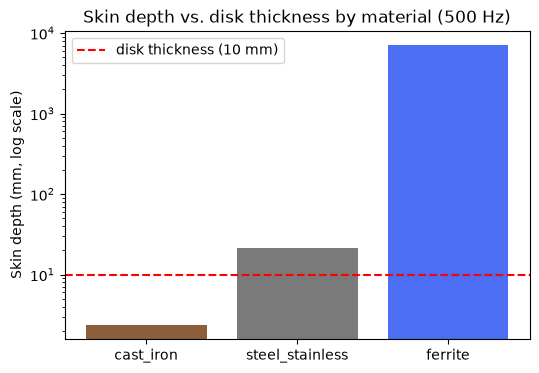

In [8]:
# 4. skin depth vs. disk thickness by material, log scale since ferrite's skin depth is ~700x the plate thickness
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(materials["material"], materials["skin_depth_mm"], color=["#8B5E3C", "#7A7A7A", "#4C6EF5"])
ax.axhline(disk_thickness_mm, color="red", linestyle="--", label=f"disk thickness ({disk_thickness_mm} mm)")
ax.set_yscale("log")
ax.set_ylabel("Skin depth (mm, log scale)")
ax.set_title("Skin depth vs. disk thickness by material (500 Hz)")
ax.legend()
plt.savefig("Images/Week1_ex5_skin_depth_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

The skin depth ratio splits the three materials into two different regimes, and the ohmic loss ranking only tracks skin depth in one of them.

**cast_iron** has a skin depth of 2.37mm against a 10mm-thick disk (ratio 0.24) - the field genuinely can't penetrate the whole plate, so eddy currents concentrate near the surface exactly like the classic induction-heating picture, and it also has the highest ohmic loss of the three.

**steel_stainless** breaks the naive "smaller skin depth -> more loss" story: its skin depth (21.5mm) is over twice the disk thickness, meaning the field reaches essentially the whole plate with no real skin confinement - yet its ohmic loss (51.7W) is close to cast_iron's (65.9W). That's because loss here isn't being driven by surface concentration at all; it's driven directly by steel's high bulk conductivity (1.1x10^6 S/m, comparable to cast_iron's 1.5x10^6) acting through the full plate volume.

**ferrite** has by far the largest skin depth (7.1m, ~700x the plate thickness) and zero meaningful skin effect, but that's not why its loss is ~0 - its conductivity (0.01 S/m) is five to six orders of magnitude below the other two, so there's essentially no free current to induce regardless of how the field distributes.

So the theoretical relationship holds only for cast_iron, where skin depth is actually the limiting factor; for steel_stainless and ferrite, conductivity magnitude alone explains the loss, and skin depth is not doing the explanatory work. No further analysis needed - this is consistent with the light-check goal of an order-of-magnitude qualitative check, not a precise theoretical match.